<div style="padding:22px 26px; border-radius:14px; background:linear-gradient(135deg,#7A0019,#9E1B32); color:white; margin-bottom:18px;">
  <div style="font-size:30px; font-weight:700; line-height:1.2;">Ablation: Input Resolution 960 vs. 640</div>
  <div style="font-size:16px; margin-top:7px; opacity:0.95;">CS4343 · Deep Learning · Final Project</div>
</div>

**Team:** Yutaro Matsuyama, Dajiro Tanimura, Markenson Adam, Regan John, Ruiz Jeronimo

Ports are small objects, and the baseline struggles most with **DisplayPort** (test AP@0.5 = 0.40) and **HDMI** (0.71).
A larger input keeps more pixels per port, which may help the detector see their shapes.
This notebook trains the same YOLOv8s at **960 × 960** and compares it with the 640 models trained in
`CS4343_Project_Port_Detection.ipynb`.

Only the input size changes. Batch size (16), optimizer, augmentation, and early stopping are the same as the baseline.

| Section | Content |
|:--|:--|
| 1 | Train the 960 model |
| 2 | Test-set comparison (per class) |
| 3 | Confusion matrices at confidence 0.25 |
| 4 | Robustness comparison |
| 5 | Summary |

## Setup and Imports

**Run `CS4343_Project_Port_Detection.ipynb` first.** This notebook reads its results from `runs/baseline`,
`runs/eval_baseline_test`, and `runs/robust_*`.

1. Put this notebook in the same Drive folder (`MyDrive/CS4343-port-detection`) as the main notebook.
2. Open it with Colab and select **Runtime → Change runtime type → T4 GPU**.
3. Choose **Runtime → Run all** and allow access to Google Drive.

| Step | Expected time on a T4 |
|:--|:--|
| Training at 960 (Section 1) | ~1 h (about 2× slower per epoch than 640) |
| Evaluation and confusion matrices (Sections 2–3) | ~3 min |
| Robustness (Section 4) | ~10–15 min |

- **Out of memory:** if training stops with `CUDA out of memory`, set `BATCH = 8` and run again.
- **Disconnected during training:** re-run the setup cells, then run
  `YOLO("runs/img960/weights/last.pt").train(resume=True)` in a new cell, set `TRAIN = False`, and run the remaining cells.
- **Already trained:** set `TRAIN = False` to reuse `runs/img960/weights/best.pt` and only run the evaluation.

In [1]:
# ---- Settings ----
QUICK_TEST = False      # True: tiny run (1 epoch, 5% of data, smaller input) only to check that everything runs
TRAIN = True            # False: skip training and reuse runs/img960/weights/best.pt
BATCH = 16              # same as the baseline; use 8 if the GPU runs out of memory
RUN_ROBUSTNESS = True   # Section 4
DRIVE_DIR = "/content/drive/MyDrive/CS4343-port-detection"  # Colab only: project folder on Google Drive

In [2]:
import os
import shutil
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/project")
    # Copy code and images to the local disk (reading images from Drive is slow).
    shutil.copytree(DRIVE_DIR, PROJECT, dirs_exist_ok=True,
                    ignore=shutil.ignore_patterns("runs", "corrupted", "example", "*.pt", "__pycache__"))
    # Keep runs/ on Drive so weights and results survive a disconnect.
    drive_runs = Path(DRIVE_DIR) / "runs"
    drive_runs.mkdir(exist_ok=True)
    if not (PROJECT / "runs").exists():
        (PROJECT / "runs").symlink_to(drive_runs)
else:
    PROJECT = Path.cwd()  # the notebook sits in the project folder

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))
assert (PROJECT / "train.py").exists(), f"train.py not found in {PROJECT}"
assert (PROJECT / "prepared" / "images" / "train").exists(), "Download prepared/ first (see README)"
print("Running in:", "Colab" if IN_COLAB else "local Jupyter", "|", PROJECT)

Mounted at /content/drive
Running in: Colab | /content/project


In [3]:
# Install Ultralytics (PyTorch is already installed in Colab).
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.9 MB/s eta 0:00:00


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from ultralytics import YOLO

from config import CLASSES, DATA, RUNS, pick_device
from evaluate import evaluate
from robustness import SEVERITY, run as run_robustness
from train import train

DEVICE = pick_device()
print("Selected device:", DEVICE)

# QUICK_TEST compares against the quick_* runs of the main notebook; its numbers are meaningless.
PREFIX = "quick_" if QUICK_TEST else ""
BASE_IMGSZ = 320 if QUICK_TEST else 640   # input size of the main notebook's models
IMGSZ = 480 if QUICK_TEST else 960        # input size of this ablation
EPOCHS = 1 if QUICK_TEST else 100
FRACTION = 0.05 if QUICK_TEST else 1.0
if QUICK_TEST:
    BATCH = 4

NAMES = {"baseline": "640 + aug", "no_aug": "640, no aug", "img960": "960 + aug"}
COLORS = {"baseline": "#2a78d6", "no_aug": "#eb6834", "img960": "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.3, "lines.linewidth": 2})

baseline_weights = RUNS / f"{PREFIX}baseline" / "weights" / "best.pt"
assert baseline_weights.exists(), f"{baseline_weights} not found. Run the main notebook first."
print("Baseline weights:", baseline_weights)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Selected device: 0
Baseline weights: /content/project/runs/baseline/weights/best.pt


# 1. Train the 960 Model

In [5]:
img960_weights = RUNS / f"{PREFIX}img960" / "weights" / "best.pt"
if TRAIN:
    img960_weights = train(f"{PREFIX}img960", epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, fraction=FRACTION)
assert img960_weights.exists(), f"{img960_weights} not found. Set TRAIN = True."
print("960 weights:", img960_weights)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=img960, nbs=64, nms=None, opset=None, optimize=False, optimize

## Learning Curves: 640 vs. 960

Validation mAP@0.5 per epoch. A curve that keeps rising longer means the larger input gives the model more to learn from.

640 + aug  epochs run:  71   best val mAP@0.5: 0.833 (epoch 57)
960 + aug  epochs run:  65   best val mAP@0.5: 0.831 (epoch 44)


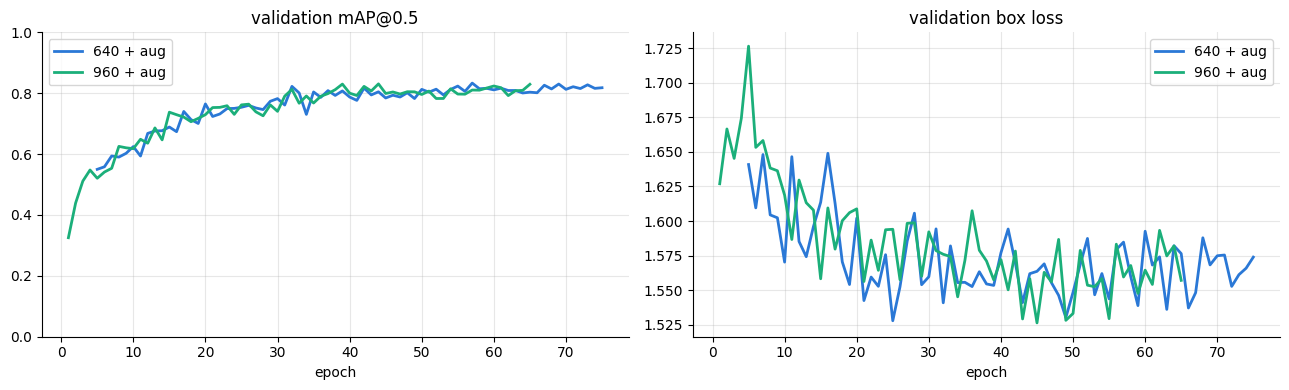

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name in ["baseline", "img960"]:
    df = pd.read_csv(RUNS / f"{PREFIX}{name}" / "results.csv")
    df.columns = df.columns.str.strip()
    axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], color=COLORS[name], label=NAMES[name])
    axes[1].plot(df["epoch"], df["val/box_loss"], color=COLORS[name], label=NAMES[name])
    best = df.loc[df["metrics/mAP50(B)"].idxmax()]
    print(f"{NAMES[name]:<10} epochs run: {len(df):>3}   best val mAP@0.5: {best['metrics/mAP50(B)']:.3f} "
          f"(epoch {int(best['epoch'])})")
axes[0].set_title("validation mAP@0.5")
axes[0].set_ylim(0, 1)
axes[1].set_title("validation box loss")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

# 2. Test-Set Comparison

The 960 model is evaluated at 960; the 640 results are read from the main notebook's output
(`runs/eval_baseline_test/per_class.csv`, `runs/eval_no_aug_test/per_class.csv`).
Success criteria: test mAP@0.5 $\ge 0.85$ and every class AP@0.5 $\ge 0.70$.

In [7]:
map960, rows = evaluate(img960_weights, split="test", imgsz=IMGSZ, name=f"eval_{PREFIX}img960_test")
per_class = {"img960": pd.DataFrame(rows).set_index("class")}
per_class["img960"].to_csv(RUNS / f"eval_{PREFIX}img960_test" / "per_class.csv")

for name in ["baseline", "no_aug"]:
    csv = RUNS / f"eval_{PREFIX}{name}_test" / "per_class.csv"
    if csv.exists():
        per_class[name] = pd.read_csv(csv).set_index("class")
    else:
        print(f"{csv} not found; skipping {name}")

ap = pd.DataFrame({NAMES[n]: t["ap50"] for n, t in per_class.items()}).reindex(CLASSES)
ap.loc["mAP@0.5"] = ap.mean()
display(ap.round(3))

success = map960 >= 0.85 and (per_class["img960"]["ap50"] >= 0.70).all()
print(f"960 + aug: test mAP@0.5 = {map960:.3f}  ->  success criteria {'MET' if success else 'NOT met'}")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 12.7±8.9 MB/s, size: 46.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/project/prepared/labels/test... 171 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 435.3it/s 0.4s
val: New cache created: /content/project/prepared/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.5it/s 7.3s
                   all        171        507      0.792      0.708      0.773      0.424
Speed: 10.3ms preprocess, 22.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/MyDrive/CS4343-port-detection/runs/eval_img960_test


,960 + aug,640 + aug,"640, no aug"
class,,,
displayport,0.493,0.403,0.310
ethernet,0.866,0.887,0.732
hdmi,0.767,0.706,0.657
usb-a,0.902,0.885,0.802
usb-c,0.770,0.765,0.692
vga,0.842,0.819,0.797
mAP@0.5,0.773,0.744,0.665


960 + aug: test mAP@0.5 = 0.773  ->  success criteria NOT met


In [ ]:
order = [n for n in ["no_aug", "baseline", "img960"] if n in per_class]
x = np.arange(len(CLASSES))
width = 0.8 / len(order)

fig, ax = plt.subplots(figsize=(11, 4))
for i, name in enumerate(order):
    values = per_class[name]["ap50"].reindex(CLASSES)
    ax.bar(x + i * width - 0.4 + width / 2, values, width * 0.92, color=COLORS[name], label=NAMES[name])
ax.axhline(0.70, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x, CLASSES)
ax.set_ylim(0, 1)
ax.set_ylabel("AP@0.5 (test)")
ax.legend()
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

# 3. Confusion Matrices at Confidence 0.25

The mAP evaluation keeps every detection down to confidence 0.001, and Ultralytics uses the same threshold for its
confusion matrix, which fills it with near-zero-confidence guesses. Here we re-run the test set at **confidence 0.25**,
a practical operating point, and use **only the confusion matrix** from these runs (their mAP is not comparable).

Columns are true classes and rows are predictions. The **background** row counts missed ports and the
**background** column counts false detections.

In [ ]:
def confusion_matrix_at(weights, imgsz, name):
    YOLO(str(weights)).val(data=str(DATA), split="test", imgsz=imgsz, conf=0.25, batch=16, device=DEVICE,
                           project=str(RUNS), name=name, exist_ok=True, verbose=False)
    return RUNS / name / "confusion_matrix_normalized.png"


cm_files = {
    "baseline": confusion_matrix_at(baseline_weights, BASE_IMGSZ, f"cm_{PREFIX}baseline"),
    "img960": confusion_matrix_at(img960_weights, IMGSZ, f"cm_{PREFIX}img960"),
}
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (name, path) in zip(axes, cm_files.items()):
    ax.imshow(plt.imread(path))
    ax.set_title(NAMES[name], fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. Robustness Comparison

The same corruptions as in the main notebook, evaluated at 960. The 640 results are read from
`runs/robust_baseline/robustness.csv` and `runs/robust_no_aug/robustness.csv`. Severity 0 is the clean test set.

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1805.7±555.2 MB/s, size: 67.0 KB)
val: Scanning /content/project/prepared/labels/test.cache... 171 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 59.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.1s
                   all        171        507      0.792      0.708      0.773      0.424
Speed: 2.0ms preprocess, 22.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2412.3±538.7 MB/s, size: 183.1 KB)
val: Scanning /content/project/corrupted/gaussian_noise_1/la

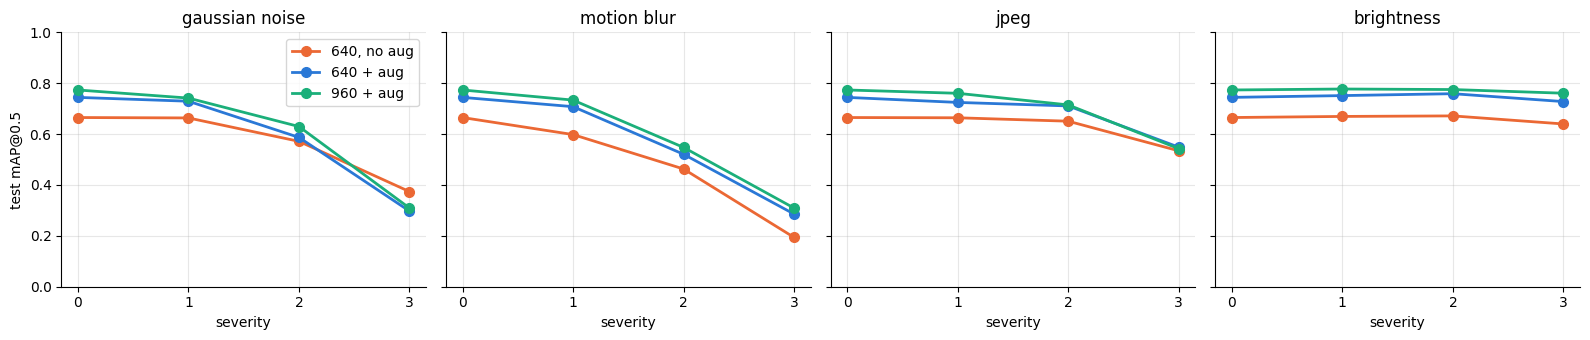

In [10]:
KINDS = ["jpeg"] if QUICK_TEST else list(SEVERITY)

robust = {}
for name in ["no_aug", "baseline"]:
    csv = RUNS / f"robust_{PREFIX}{name}" / "robustness.csv"
    if csv.exists():
        robust[name] = pd.read_csv(csv)
    else:
        print(f"{csv} not found; skipping {name}")
if RUN_ROBUSTNESS:
    robust["img960"] = pd.DataFrame(run_robustness(img960_weights, imgsz=IMGSZ, kinds=KINDS))

fig, axes = plt.subplots(1, len(KINDS), figsize=(4 * len(KINDS), 3.5), sharey=True, squeeze=False)
for ax, kind in zip(axes[0], KINDS):
    for name, df in robust.items():
        rows = pd.concat([df[df["corruption"] == "clean"], df[df["corruption"] == kind]])
        ax.plot(rows["severity"], rows["map50"], marker="o", markersize=7, color=COLORS[name], label=NAMES[name])
    ax.set_title(kind.replace("_", " "))
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xlabel("severity")
    ax.set_ylim(0, 1)
axes[0, 0].set_ylabel("test mAP@0.5")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

# 5. Summary

In [11]:
summary = pd.DataFrame({
    NAMES[n]: {
        "test mAP@0.5": t["ap50"].mean(),
        "displayport AP@0.5": t.loc["displayport", "ap50"],
        "hdmi AP@0.5": t.loc["hdmi", "ap50"],
        "lowest class AP@0.5": t["ap50"].min(),
    }
    for n, t in per_class.items()
}).T
for name, df in robust.items():
    clean = df.loc[df["corruption"] == "clean", "map50"].item()
    worst = df[df["severity"] == 3]["map50"]
    summary.loc[NAMES[name], "mean mAP@0.5 drop at severity 3"] = clean - worst.mean()
display(summary.round(3))

,test mAP@0.5,displayport AP@0.5,hdmi AP@0.5,lowest class AP@0.5,mean mAP@0.5 drop at severity 3
960 + aug,0.773,0.493,0.767,0.493,0.293
640 + aug,0.744,0.403,0.706,0.403,0.279
"640, no aug",0.665,0.310,0.657,0.310,0.230
